In [82]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [83]:
df = pd.read_csv('used_device_data.csv')

In [84]:
df

,device_brand,os,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3449,Asus,Android,15.34,yes,no,NaN,8.0,64.0,6.0,5000.0,190.0,2019,232,4.492337,6.483872
3450,Asus,Android,15.24,yes,no,13.0,8.0,128.0,8.0,4000.0,200.0,2018,541,5.037732,6.251538
3451,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,3.0,4000.0,165.0,2020,201,4.357350,4.528829
3452,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,2.0,4000.0,160.0,2020,149,4.349762,4.624188


### Variables
* **device_brand**: Name of manufacturing brand
* **os**: OS on which the device runs
* **screen_size**: Size of the screen in cm
* **4g**: Whether 4G is available or not
* **5g**: Whether 5G is available or not
* **front_camera_mp**: Resolution of the rear camera in megapixels
* **back_camera_mp**: Resolution of the front camera in megapixels
* **internal_memory**: Amount of internal memory (ROM) in GB
* **ram**: Amount of RAM in GB
* **battery**: Energy capacity of the device battery in mAh
* **weight**: Weight of the device in grams
* **release_year**: Year when the device model was released
* **days_used**: Number of days the used/refurbished device has been used
* **normalized_new_price**: Normalized price of a new device of the same model
* **normalized_used_price** (TARGET): Normalized price of the used/refurbished device

In [85]:
df.columns

Index(['device_brand', 'os', 'screen_size', '4g', '5g', 'rear_camera_mp',
       'front_camera_mp', 'internal_memory', 'ram', 'battery', 'weight',
       'release_year', 'days_used', 'normalized_used_price',
       'normalized_new_price'],
      dtype='object')

In [86]:
df.describe()

,screen_size,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454.000000,3275.000000,3452.000000,3450.000000,3450.000000,3448.000000,3447.000000,3454.000000,3454.000000,3454.000000,3454.000000
mean,13.713115,9.460208,6.554229,54.573099,4.036122,3133.402697,182.751871,2015.965258,674.869716,4.364712,5.233107
std,3.805280,4.815461,6.970372,84.972371,1.365105,1299.682844,88.413228,2.298455,248.580166,0.588914,0.683637
min,5.080000,0.080000,0.000000,0.010000,0.020000,500.000000,69.000000,2013.000000,91.000000,1.536867,2.901422
25%,12.700000,5.000000,2.000000,16.000000,4.000000,2100.000000,142.000000,2014.000000,533.500000,4.033931,4.790342
50%,12.830000,8.000000,5.000000,32.000000,4.000000,3000.000000,160.000000,2015.500000,690.500000,4.405133,5.245892
75%,15.340000,13.000000,8.000000,64.000000,4.000000,4000.000000,185.000000,2018.000000,868.750000,4.755700,5.673718
max,30.710000,48.000000,32.000000,1024.000000,12.000000,9720.000000,855.000000,2020.000000,1094.000000,6.619433,7.847841


In [87]:
df.dtypes

device_brand              object
os                        object
screen_size              float64
4g                        object
5g                        object
rear_camera_mp           float64
front_camera_mp          float64
internal_memory          float64
ram                      float64
battery                  float64
weight                   float64
release_year               int64
days_used                  int64
normalized_used_price    float64
normalized_new_price     float64
dtype: object

In [88]:
df.shape

(3454, 15)

In [89]:
duplicated_rows= df[df.duplicated()]
duplicated_rows.shape

(0, 15)

Good thing, that there is no duplicated rows.

In [90]:
df.isnull().sum()

device_brand               0
os                         0
screen_size                0
4g                         0
5g                         0
rear_camera_mp           179
front_camera_mp            2
internal_memory            4
ram                        4
battery                    6
weight                     7
release_year               0
days_used                  0
normalized_used_price      0
normalized_new_price       0
dtype: int64

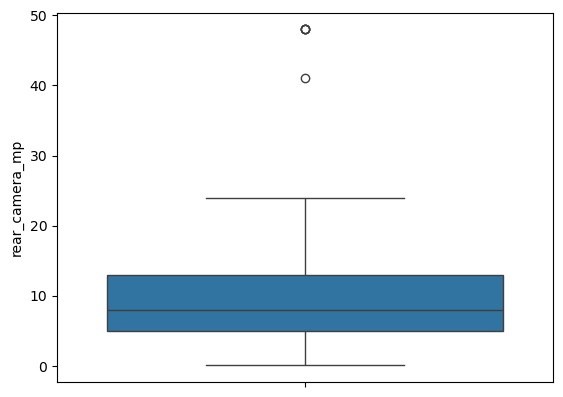

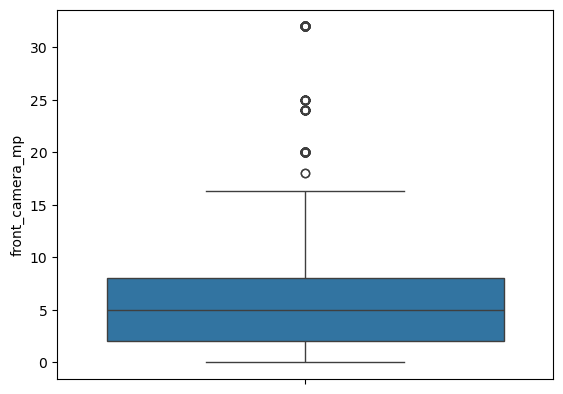

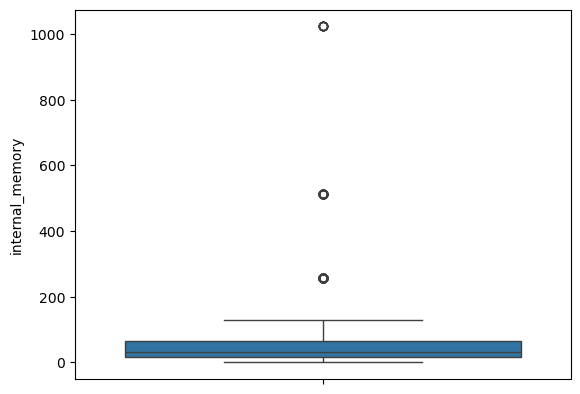

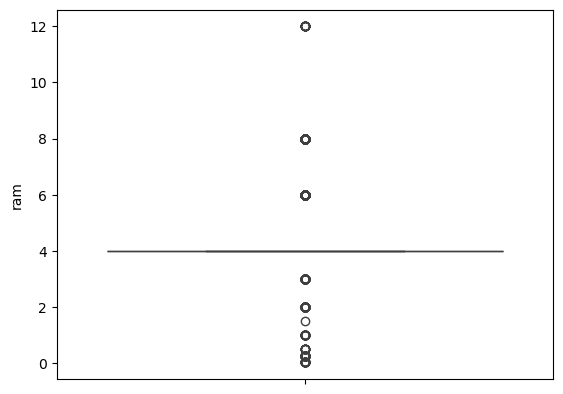

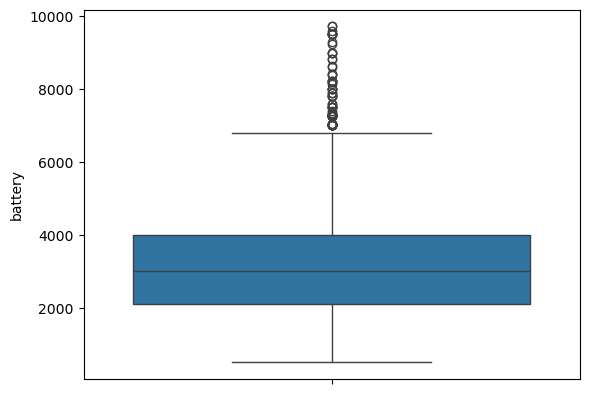

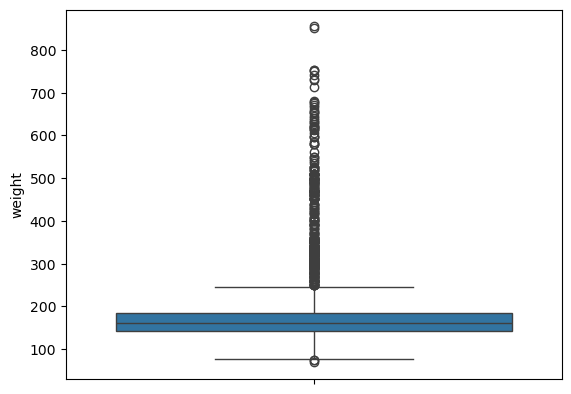

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt 

features=['rear_camera_mp','front_camera_mp','internal_memory','ram','battery','weight']

for i in features:
    sns.boxplot(df[i])
    plt.show()
    




In [92]:
for i in features:
    a=df[i].median()
    print(i,' median value : ', a)
    df[i]= df[i].fillna(a)

rear_camera_mp  median value :  8.0
front_camera_mp  median value :  5.0
internal_memory  median value :  32.0
ram  median value :  4.0
battery  median value :  3000.0
weight  median value :  160.0


In [93]:
df.isnull().sum()

device_brand             0
os                       0
screen_size              0
4g                       0
5g                       0
rear_camera_mp           0
front_camera_mp          0
internal_memory          0
ram                      0
battery                  0
weight                   0
release_year             0
days_used                0
normalized_used_price    0
normalized_new_price     0
dtype: int64

In [94]:
num_features=[feature for feature in df.columns if df[feature].dtype != 'O']
num_features

['screen_size',
 'rear_camera_mp',
 'front_camera_mp',
 'internal_memory',
 'ram',
 'battery',
 'weight',
 'release_year',
 'days_used',
 'normalized_used_price',
 'normalized_new_price']

In [95]:
cat_features=[feature for feature in df.columns if df[feature].dtype == 'O']
cat_features

['device_brand', 'os', '4g', '5g']

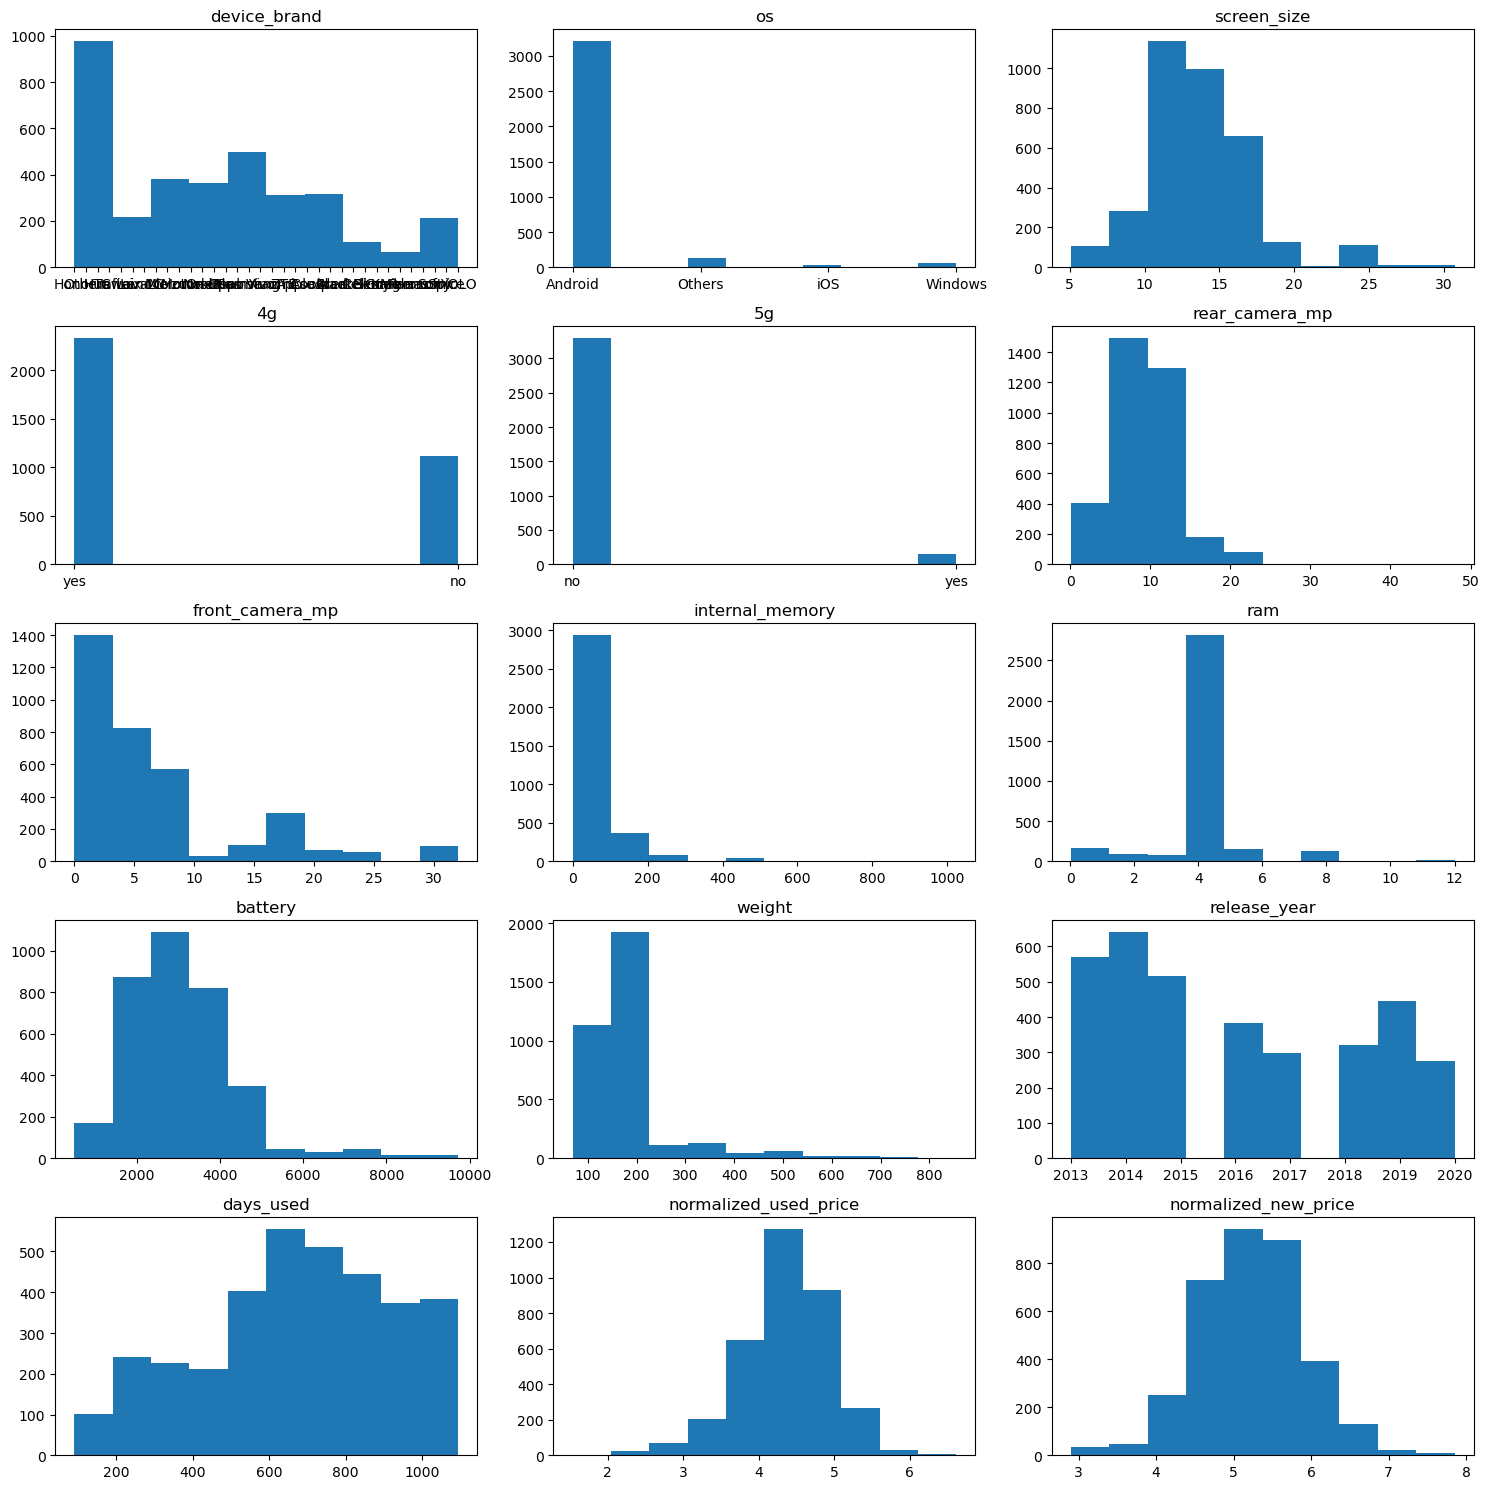

In [ ]:
fig,axs= plt.subplots(5,3,figsize=(15, 15))

axs = axs.ravel()
for i, feature in enumerate(df.columns):
    axs[i].hist(df[feature])
    axs[i].set_title(feature)
plt.tight_layout()
plt.show()



In [97]:
#storage vs price
b= df.groupby("internal_memory")["normalized_used_price"].mean()
b

internal_memory
0.01       3.097386
0.06       3.294826
0.10       3.393485
0.20       3.130664
0.50       2.530526
4.00       3.815567
8.00       3.880848
16.00      4.114984
24.00      3.151453
32.00      4.311966
64.00      4.751511
128.00     4.985526
256.00     4.725747
512.00     3.821371
1024.00    4.630121
Name: normalized_used_price, dtype: float64

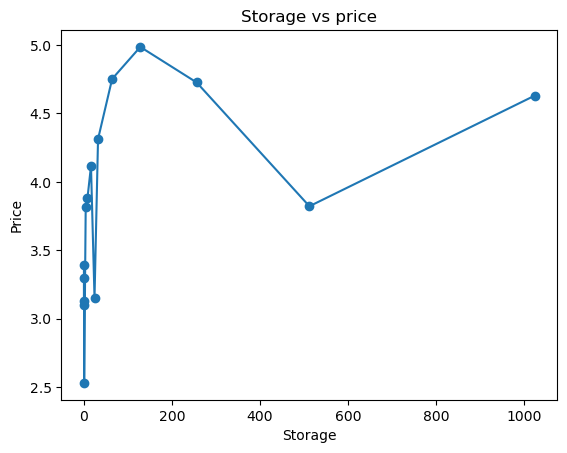

In [98]:
plt.plot(b.index, b.values , marker="o")
plt.title("Storage vs price")
plt.xlabel("Storage")
plt.ylabel("Price")
plt.show()

In [99]:
# effect of 5g support 
c= df.groupby("5g")["normalized_used_price"].mean()
c

5g
no     4.325089
yes    5.225482
Name: normalized_used_price, dtype: float64

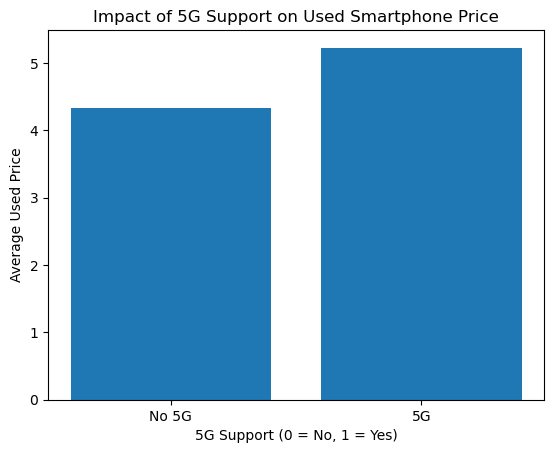

In [100]:
c = df.groupby("5g")["normalized_used_price"].mean()

plt.bar(c.index, c.values)
plt.xticks([0,1], ["No 5G","5G"])
plt.xlabel("5G Support (0 = No, 1 = Yes)")
plt.ylabel("Average Used Price")
plt.title("Impact of 5G Support on Used Smartphone Price")

plt.show()

In [101]:
# effect of days used 
d= df.groupby("days_used")["normalized_used_price"].mean()
d

days_used
91      5.009134
92      4.872511
93      4.322144
96      4.686934
97      4.725522
          ...   
1090    4.230922
1091    4.040850
1092    3.581539
1093    3.790502
1094    4.405056
Name: normalized_used_price, Length: 924, dtype: float64

C:\Users\Shailesh\AppData\Local\Temp\ipykernel_22684\2220644752.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d = df.groupby("days_group")["normalized_used_price"].mean()


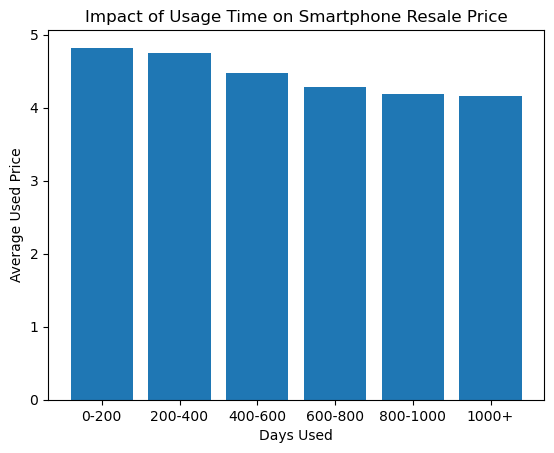

In [102]:


df["days_group"] = pd.cut(
    df["days_used"],
    bins=[0,200,400,600,800,1000,1200],
    labels=["0-200","200-400","400-600","600-800","800-1000","1000+"]
)

d = df.groupby("days_group")["normalized_used_price"].mean()

plt.bar(d.index, d.values)

plt.xlabel("Days Used")
plt.ylabel("Average Used Price")
plt.title("Impact of Usage Time on Smartphone Resale Price")

plt.show()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33],
 [Text(0, 0, 'Others'),
  Text(1, 0, 'Samsung'),
  Text(2, 0, 'Huawei'),
  Text(3, 0, 'LG'),
  Text(4, 0, 'Lenovo'),
  Text(5, 0, 'ZTE'),
  Text(6, 0, 'Xiaomi'),
  Text(7, 0, 'Oppo'),
  Text(8, 0, 'Asus'),
  Text(9, 0, 'Alcatel'),
  Text(10, 0, 'Micromax'),
  Text(11, 0, 'Vivo'),
  Text(12, 0, 'Honor'),
  Text(13, 0, 'HTC'),
  Text(14, 0, 'Nokia'),
  Text(15, 0, 'Motorola'),
  Text(16, 0, 'Sony'),
  Text(17, 0, 'Meizu'),
  Text(18, 0, 'Gionee'),
  Text(19, 0, 'Acer'),
  Text(20, 0, 'XOLO'),
  Text(21, 0, 'Panasonic'),
  Text(22, 0, 'Realme'),
  Text(23, 0, 'Apple'),
  Text(24, 0, 'Lava'),
  Text(25, 0, 'Celkon'),
  Text(26, 0, 'Spice'),
  Text(27, 0, 'Karbonn'),
  Text(28, 0, 'Coolpad'),
  Text(29, 0, 'BlackBerry'),
  Text(30, 0, 'Microsoft'),
  Text(31, 0, 'OnePlus'),
  Text(32, 0, 'Google'),


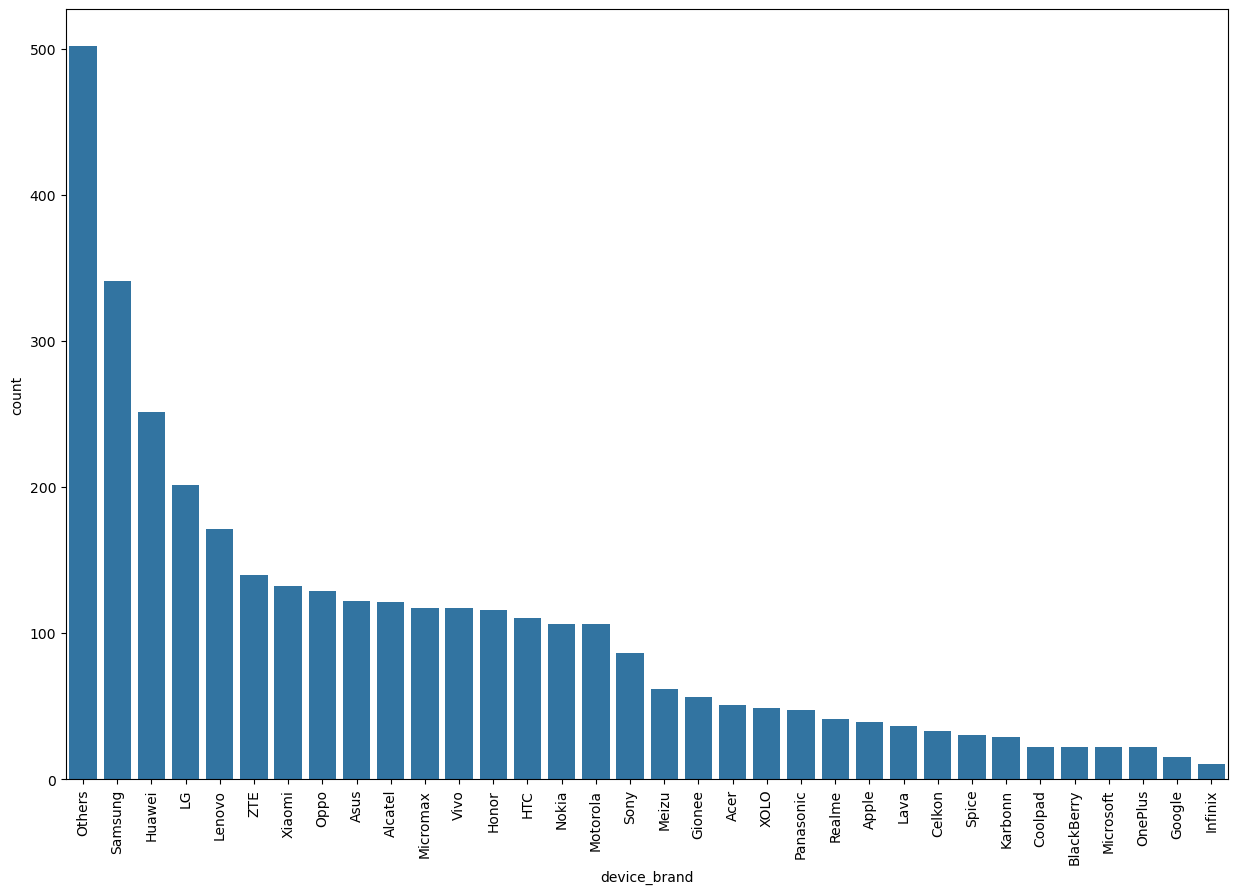

In [103]:
fig= plt.figure(figsize=(15,10))
sns.countplot(x=df.device_brand,order=df["device_brand"].value_counts().index)
plt.xticks(rotation=90)

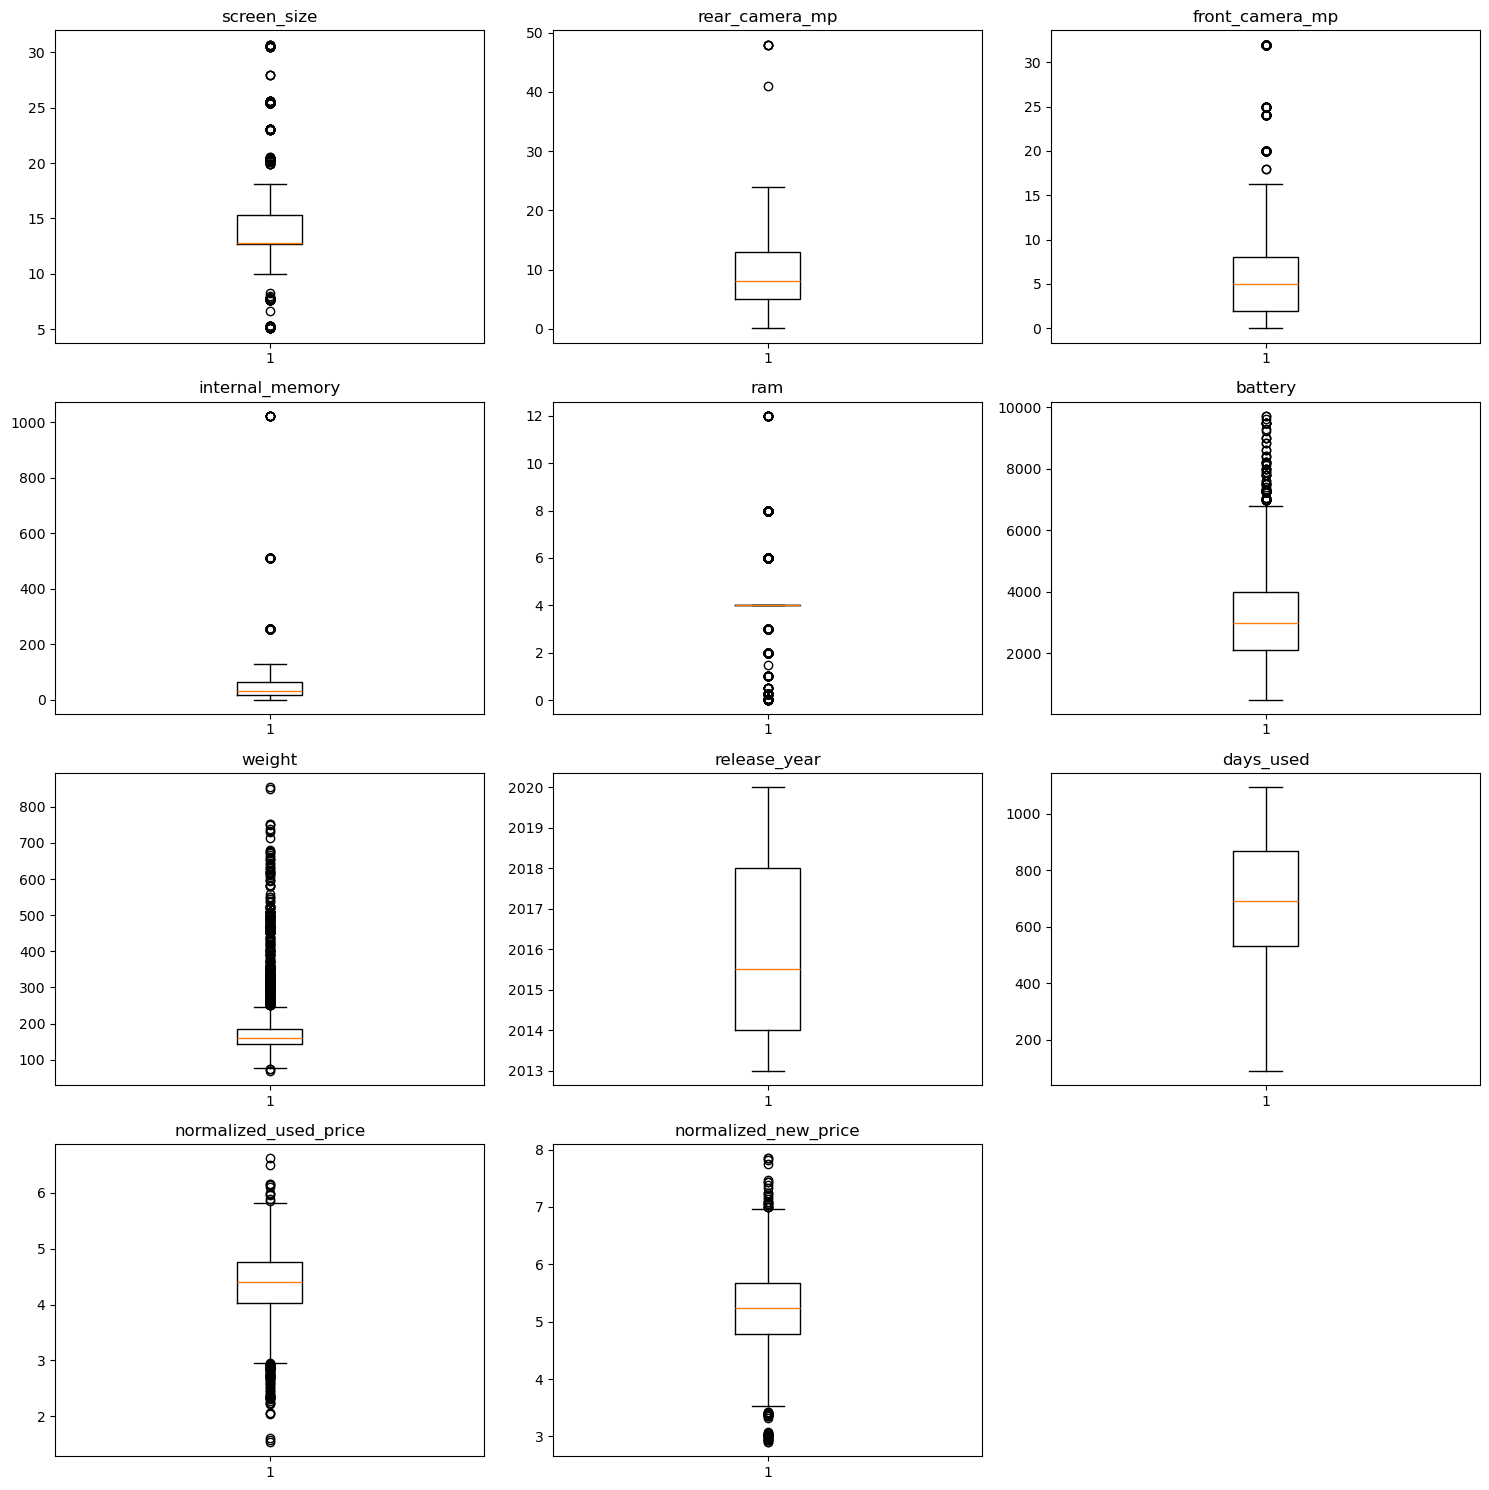

In [ ]:
fig,axs= plt.subplots(4,3,figsize=(15, 15))

axs = axs.ravel()
for i, feature in enumerate(num_features):
    
    axs[i].boxplot(df[feature])
    axs[i].set_title(feature)


fig.delaxes(axs[-1])

plt.tight_layout()

plt.show()

We could see the outliers in the above features. We'll correct it in the upcoming sections

In [105]:
features=['screen_size',
 'front_camera_mp',
 'ram',
 'battery',
 'weight',
 'normalized_used_price',
 'normalized_new_price']
for i in features:
    lower = df[i].quantile(0.10)
    upper = df[i].quantile(0.90)
    df[i] = np.where(df[i] <lower, lower,df[i])
    df[i] = np.where(df[i] >upper, upper,df[i])
    print('Feature: ',i)
    print('Skewness value: ',df[i].skew())
    print('\n')
    

Feature:  screen_size
Skewness value:  0.24196057812708158


Feature:  front_camera_mp
Skewness value:  0.8742550451761658


Feature:  ram
Skewness value:  0.0


Feature:  battery
Skewness value:  0.16546880955819707


Feature:  weight
Skewness value:  1.1632954167338405


Feature:  normalized_used_price
Skewness value:  -0.14433266108803783


Feature:  normalized_new_price
Skewness value:  -0.02125569017206945




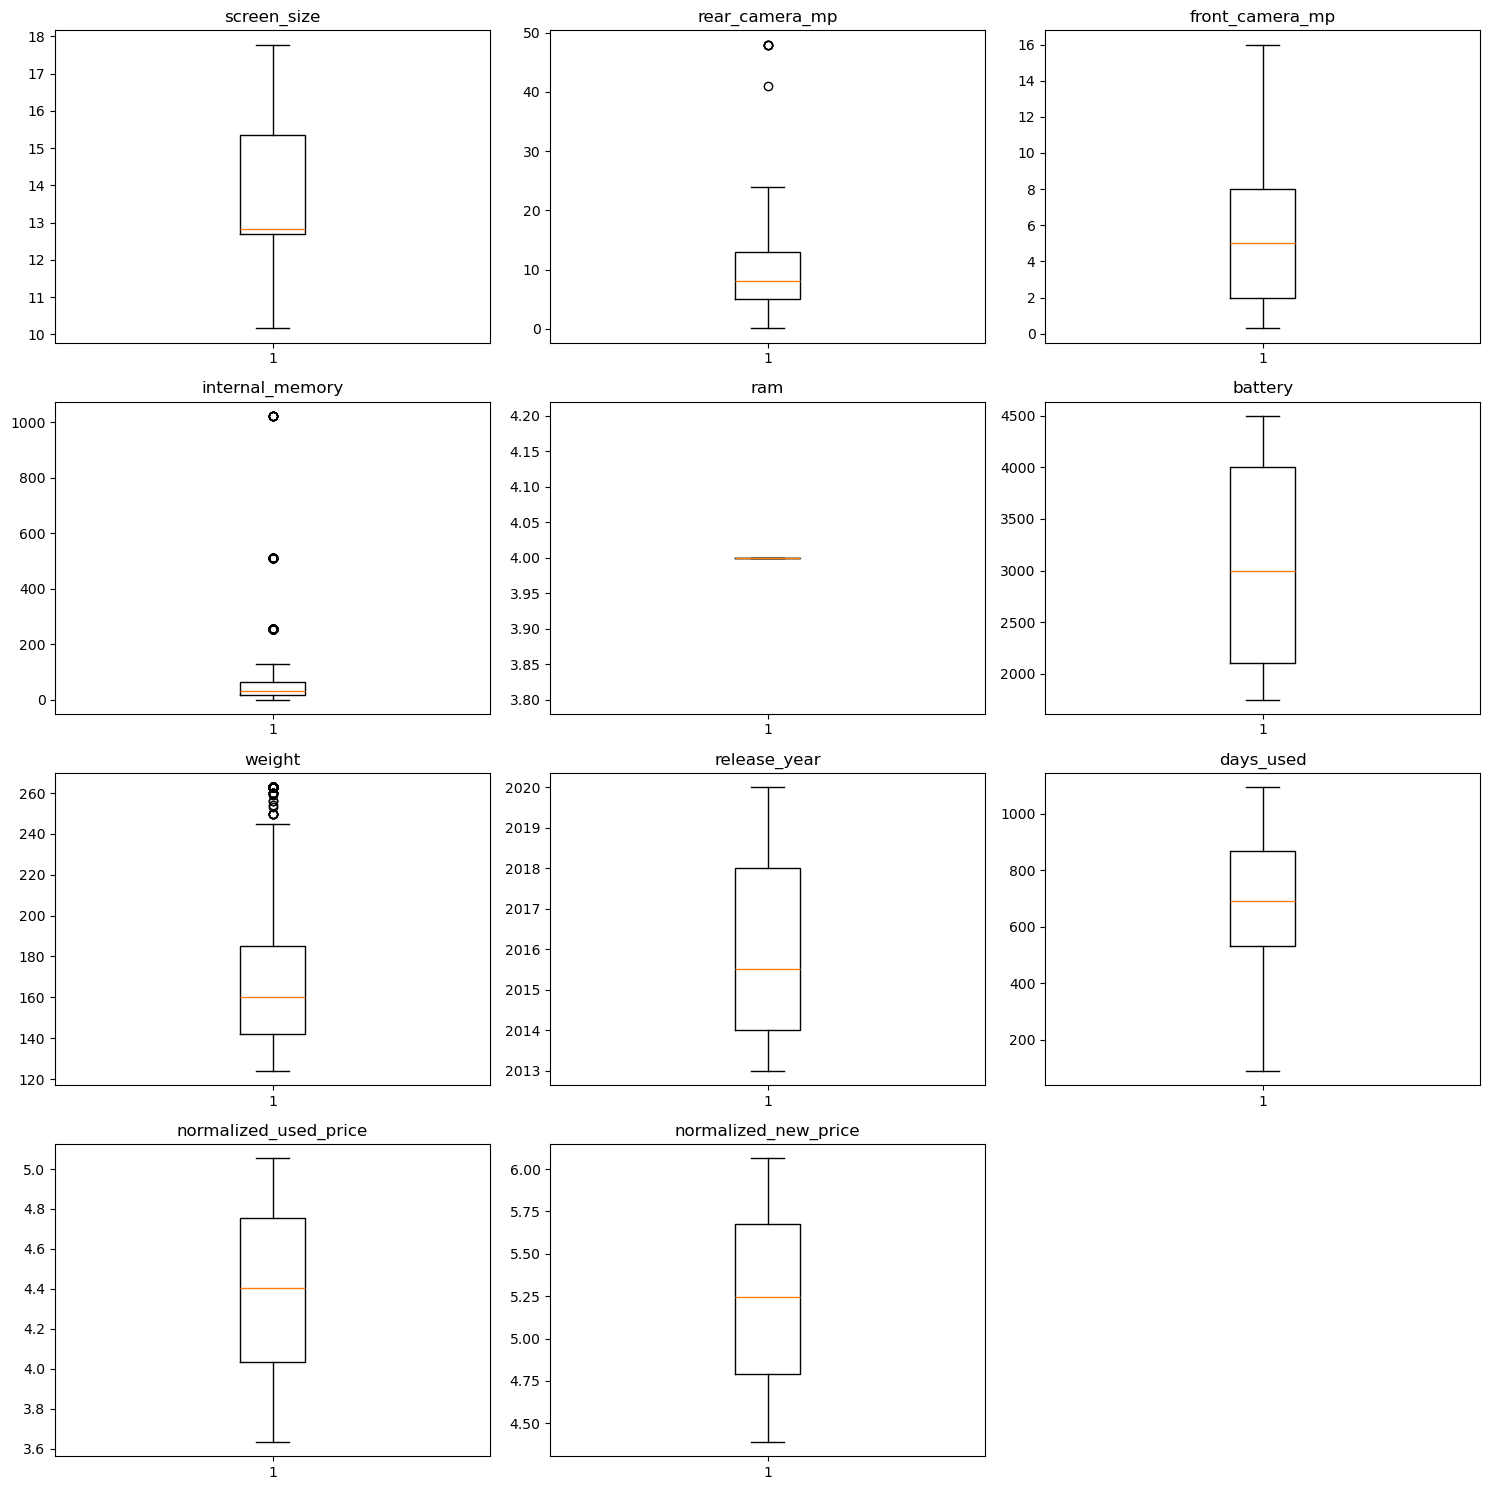

In [ ]:
fig,axs= plt.subplots(4,3,figsize=(15, 15))

axs = axs.ravel()
for i, feature in enumerate(num_features):
    
    axs[i].boxplot(df[feature])
    axs[i].set_title(feature)


fig.delaxes(axs[-1])

plt.tight_layout()

plt.show()

Treating rear_camera_mp, internal_memory and battery separately

In [107]:
upper= df.rear_camera_mp.quantile(0.95)
df.rear_camera_mp= np.where(df.rear_camera_mp>upper,upper,df.rear_camera_mp)

upper= df.internal_memory.quantile(0.9)
df.internal_memory= np.where(df.internal_memory>upper,upper,df.internal_memory)

upper= df.weight.quantile(0.8)
df.weight= np.where(df.weight>upper,upper,df.weight)

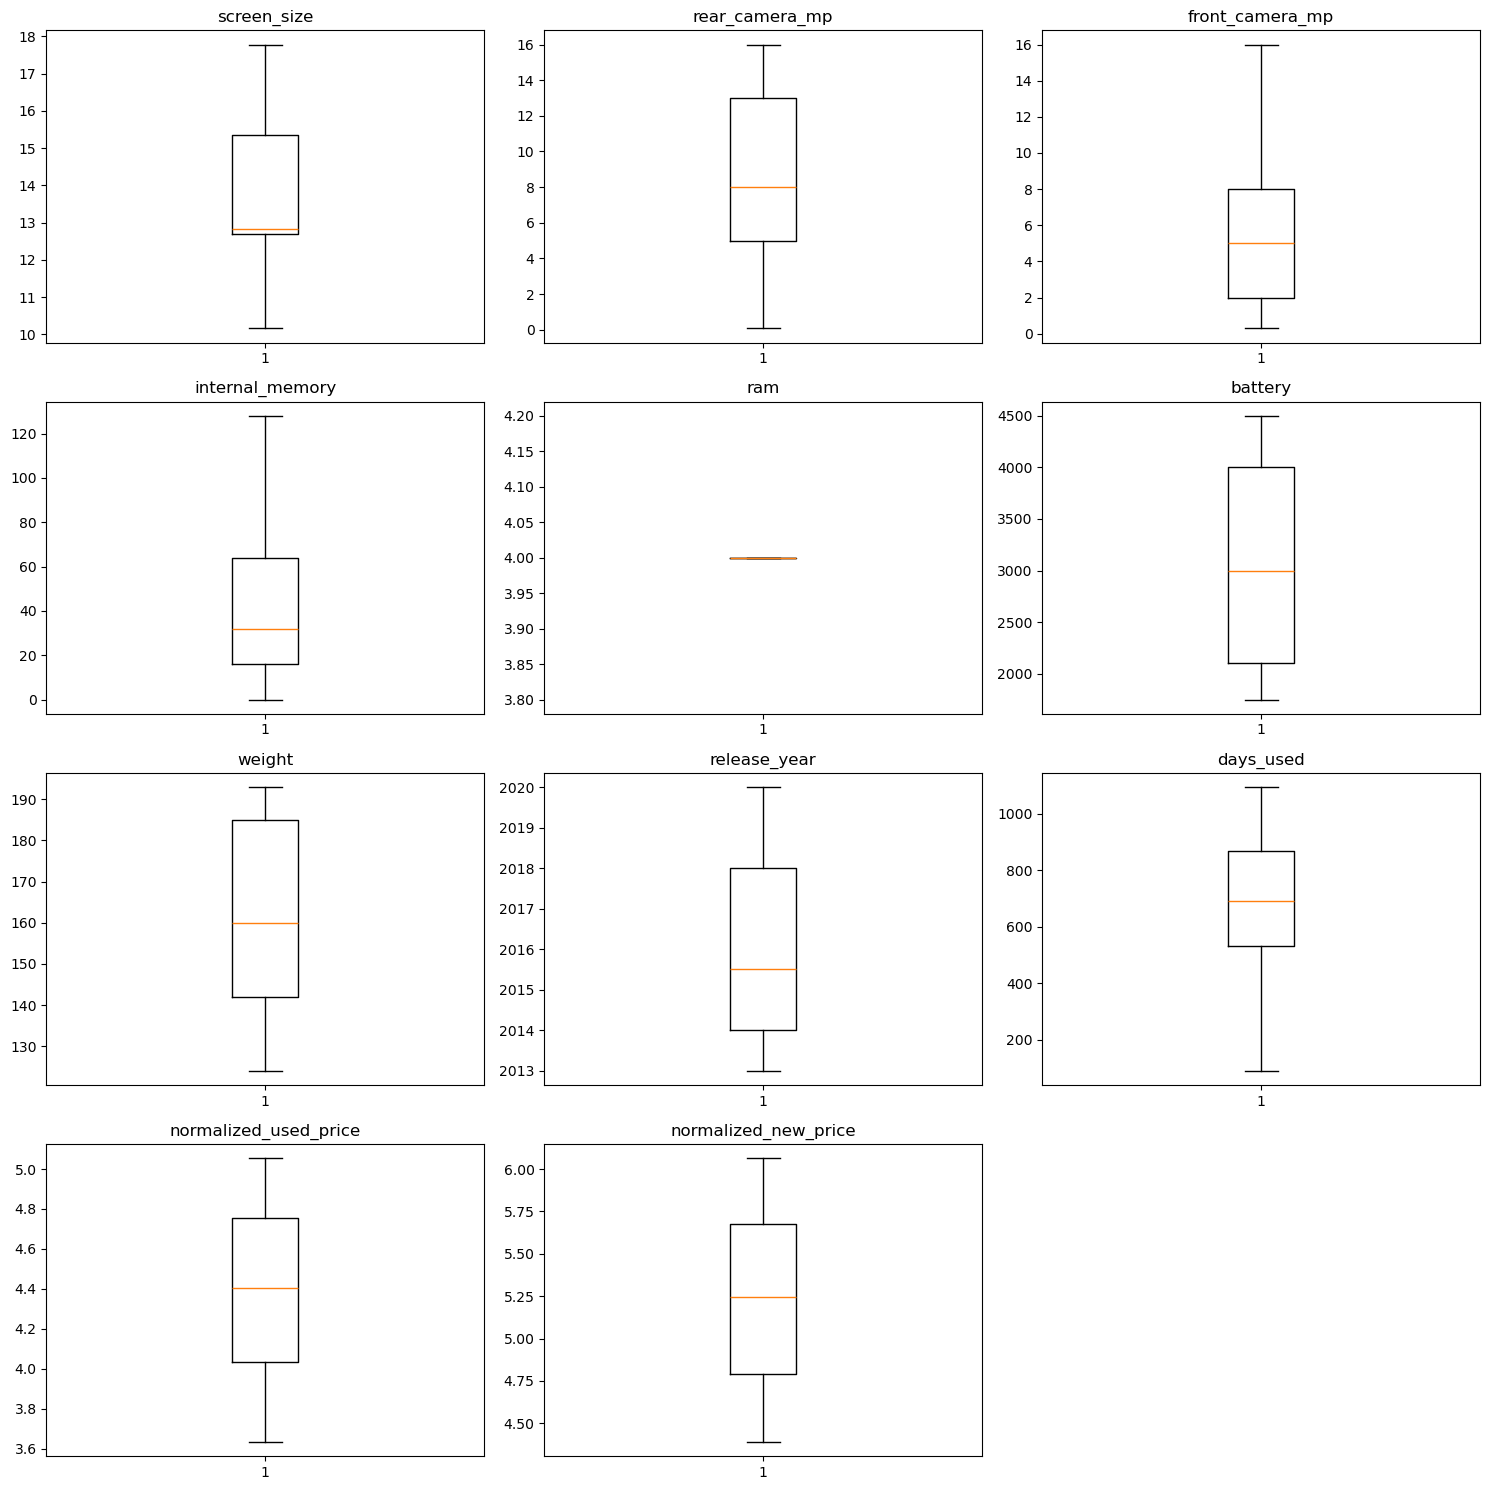

In [ ]:
fig,axs= plt.subplots(4,3,figsize=(15, 15))

axs = axs.ravel()
for i, feature in enumerate(num_features):
    
    axs[i].boxplot(df[feature])
    axs[i].set_title(feature)

 
fig.delaxes(axs[-1])

plt.tight_layout()

plt.show()

In [109]:
bi_num=['screen_size',
 'rear_camera_mp',
 'front_camera_mp',
 'internal_memory',
 'ram',
 'battery',
 'weight',
 'release_year',
 'days_used',
 'normalized_new_price']


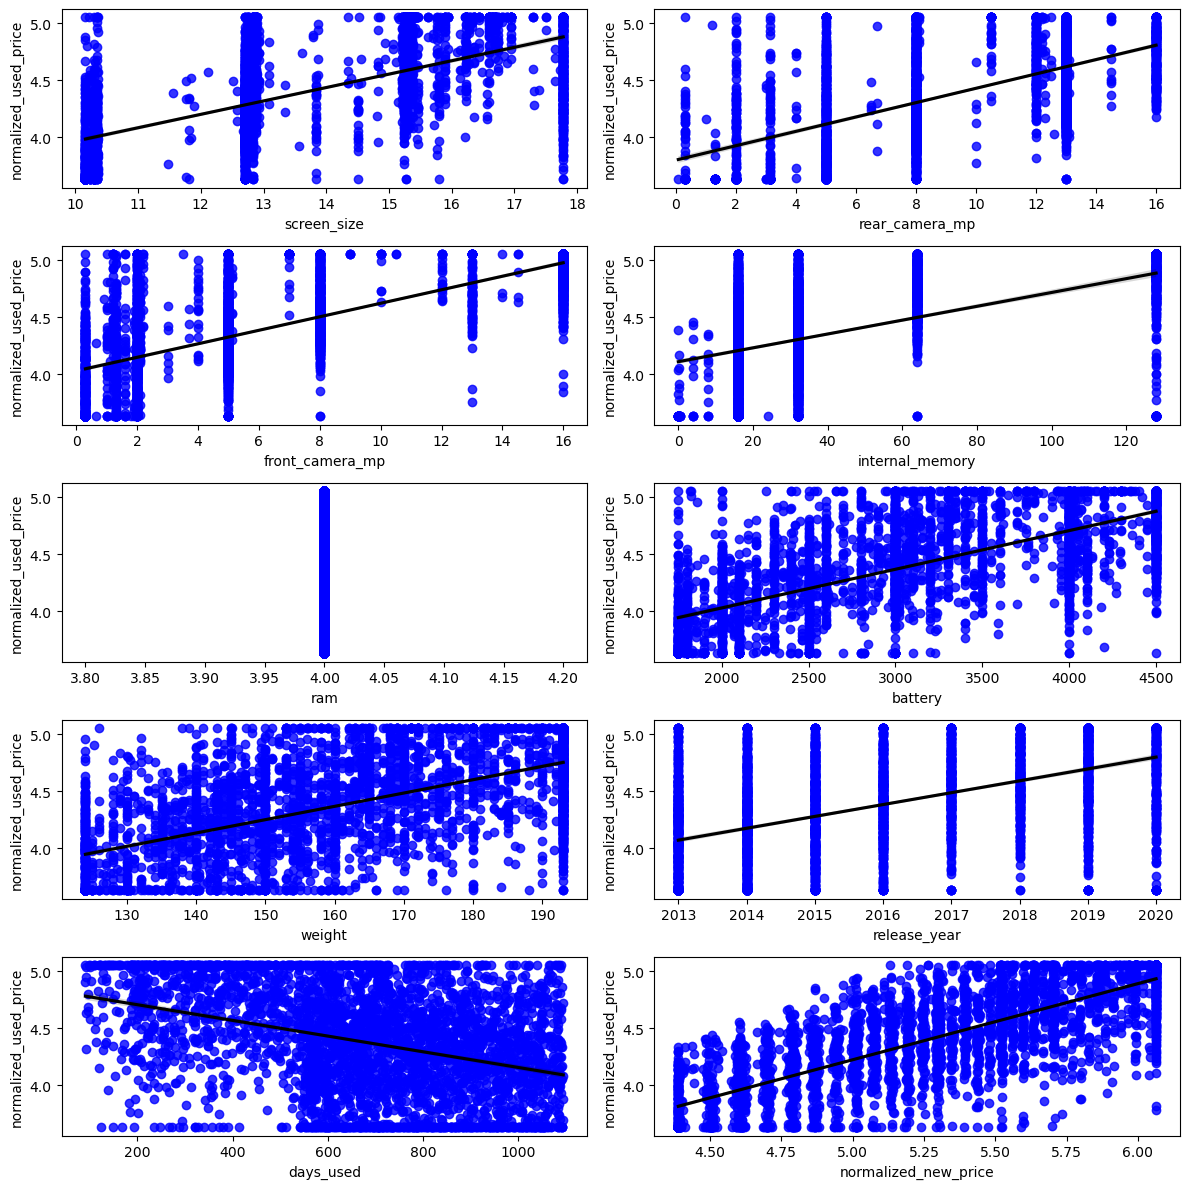

In [110]:
fig,axs= plt.subplots(5,2,figsize=(12,12))
axs=axs.ravel()
for i,ax in enumerate(axs):

    sns.regplot(x=bi_num[i],y='normalized_used_price',data=df,ax=ax,color='black',scatter_kws={"color":"blue"})

plt.tight_layout()
plt.show()


In [ ]:
X= df.drop('normalized_used_price',axis=1)
y= df.normalized_used_price


for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()


X.dtypes == object

device_brand            False
os                      False
screen_size             False
4g                      False
5g                      False
rear_camera_mp          False
front_camera_mp         False
internal_memory         False
ram                     False
battery                 False
weight                  False
release_year            False
days_used               False
normalized_new_price    False
days_group              False
dtype: bool

In [ ]:
from sklearn.model_selection import train_test_split


def dataset(X,y):
    train_full_X, val_X, train_full_y, val_y = train_test_split(X, y,test_size=0.2,random_state = 0)


    train_X, test_X, train_y, test_y = train_test_split(train_full_X, train_full_y, test_size=0.25,random_state = 0)
    return (train_X, val_X, train_y, val_y)

In [113]:
scores=[]

In [114]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

X= df.drop('normalized_used_price',axis=1)
y= df.normalized_used_price

X=pd.get_dummies(X)


#X= scale(X)
#X= PCAx(X)

X_train,X_val,y_train,y_val= dataset(X,y)

decision_model1= DecisionTreeRegressor(random_state=1)
decision_model1.fit(X_train, y_train)
preds= decision_model1.predict(X_val)

r2= r2_score(y_val,preds)
MSE= mean_squared_error(y_val,preds)


a= "Decision Tree Regreesion with all features"
print(a)
print("R2: ",round(r2,4))
print("MSE: ",round(MSE,4))

scores.append((a,round(r2,4),round(MSE,4)))


Decision Tree Regreesion with all features
R2:  0.6804
MSE:  0.0693


In [115]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
X= df.drop('normalized_used_price',axis=1)
y= df.normalized_used_price

X=pd.get_dummies(X)


# X= scale(X)
# X= PCAx(X)
X_train,X_val,y_train,y_val= dataset(X,y)

random_model1= RandomForestRegressor(random_state=1)
random_model1.fit(X_train, y_train)
preds= random_model1.predict(X_val)

r2= r2_score(y_val,preds)
MSE= mean_squared_error(y_val,preds)


a= "Random Forest Regression with all features"
print(a)
print("R2: ",round(r2,4))
print("MSE: ",round(MSE,4))

scores.append((a,round(r2,4),round(MSE,4)))


Random Forest Regression with all features
R2:  0.8251
MSE:  0.0379


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = df.drop('normalized_used_price', axis=1)
y = df['normalized_used_price']

X = pd.get_dummies(X)


X_train, X_val, y_train, y_val = dataset(X, y)

linear_model1 = LinearRegression()
linear_model1.fit(X_train, y_train)

preds = linear_model1.predict(X_val)


r2 = r2_score(y_val, preds)
MSE = mean_squared_error(y_val, preds)

a = "Linear Regression with all features"

print(a)
print("R2:", round(r2, 4))
print("MSE:", round(MSE, 4))


scores.append((a, round(r2, 4), round(MSE, 4)))

Linear Regression with all features
R2: 0.8319
MSE: 0.0365


In [117]:
scores

[('Decision Tree Regreesion with all features', 0.6804, 0.0693),
 ('Random Forest Regression with all features', 0.8251, 0.0379),
 ('Linear Regression with all features', 0.8319, 0.0365)]

In [ ]:

import joblib
max_price = df['normalized_used_price'].max()  # usually 1, but safe

# better: use original scale reference
scale_factor = df['normalized_new_price'].max()

joblib.dump(scale_factor, "scale.pkl")

['scale.pkl']

In [119]:


joblib.dump(linear_model1, "model.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']